In [1]:
import torch
import pandas as pd
import numpy as np
import random
from pyfaidx import Fasta

import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [2]:
# functions

def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()
    
    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    valid_bases = list(base_to_int.keys())

    # Step 1: Convert sequence to integer encoding with random base for 'N'
    encoded_indices = []
    for base in sequence:
        if base in base_to_int:
            encoded_indices.append(base_to_int[base])
        else:
            random_base = random.choice(valid_bases)
            encoded_indices.append(base_to_int[random_base])

    # Step 2: One-hot encode the sequence
    encoded_sequence = np.array(encoded_indices)
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence


def upper_triangular_to_vector_skip_two_diagonals(matrix):
    """
    Extracts the upper triangular part of a square matrix (excluding the first two diagonals) 
    and transforms it into a vector.
    
    Parameters:
        matrix (np.ndarray): A 2D numpy matrix of shape (512, 512).
        
    Returns:
        np.ndarray: A 1D array containing the upper triangular elements (excluding the first two diagonals).
    """
    if matrix.shape != (512, 512):
        raise ValueError("Input matrix must be of shape (512, 512).")
    
    # Extract the upper triangular part excluding the first two diagonals
    upper_triangular_vector = matrix[np.triu_indices(512, k=2)]
    
    return upper_triangular_vector


def fragment_indices_in_upper_triangular(matrix_size=512, fragment_mask=None):
    """
    Given a binary mask for a fragment in a (448, 448) matrix, find the corresponding indices 
    within the upper triangular output vector (excluding the first two diagonals).

    Parameters:
        matrix_size (int): The size of the square matrix (default: 448).
        fragment_mask (np.ndarray): A boolean mask of shape (448, 448) marking the fragment.

    Returns:
        np.ndarray: Indices in the upper triangular vector corresponding to the fragment.
    """
    if fragment_mask.shape != (matrix_size, matrix_size):
        raise ValueError("Fragment mask must be of shape (448, 448).")

    # Get the upper triangular indices skipping two diagonals
    row_indices, col_indices = np.triu_indices(matrix_size, k=2)
    
    # Identify which of these indices are in the fragment
    selected_indices = np.where(fragment_mask[row_indices, col_indices])[0]
    
    return selected_indices


def store_tower_output(ohe_sequence, model, path):
    x = model.conv_block_1(ohe_sequence)
    x = model.conv_tower(x)
    # save the tensor
    torch.save(x, path)
    torch.cuda.empty_cache()

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1430092/ipykernel_3201504/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
FOLD = 2

In [6]:
df = pd.read_csv(f"/scratch1/smaruj/genomic_flat_regions/flat_regions_chrom_states_tsv/fold{FOLD}_selected_genomic_windows_centered_chrom_states.tsv", sep="\t")

In [7]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [ ]:
# def create_symmetric_square_ring_mask(shape=(512, 512), center=(256, 281),
#                                       center_size=3, gap_width=1, ring_width=1,
#                                       center_value=0.5, ring_value=1e-10):
#     """
#     Create a symmetric square-ring mask centered at a given location with a 3x3 center,
#     a gap, and a surrounding ring.

#     Parameters:
#     - shape: (rows, cols) of the mask
#     - center: (row, col) of the center
#     - center_size: side length of central square (default 3)
#     - gap_width: width of the gap surrounding the center
#     - ring_width: width of the ring surrounding the gap
#     - center_value: value to assign to the center square
#     - ring_value: value to assign to the outer ring

#     Returns:
#     - mask: 2D numpy array with specified values and symmetry along main diagonal
#     """
#     H, W = shape
#     r0, c0 = center
#     mask = np.zeros((H, W), dtype=float)

#     # Half sizes
#     half_center = center_size // 2
#     total_half = half_center + gap_width + ring_width

#     # Define bounds for center
#     r_start = r0 - half_center
#     r_end = r0 + half_center + 1
    # c_start = c0 - half_center
    # c_end = c0 + half_center + 1

    # # Assign center values
    # mask[r_start:r_end, c_start:c_end] = center_value

    # # Define bounds for ring
    # ring_r_start = r0 - total_half
    # ring_r_end = r0 + total_half + 1
    # ring_c_start = c0 - total_half
    # ring_c_end = c0 + total_half + 1

    # # Apply ring values (excluding center and gap)
    # for r in range(ring_r_start, ring_r_end):
    #     for c in range(ring_c_start, ring_c_end):
    #         # Skip if out of bounds
    #         if r < 0 or r >= H or c < 0 or c >= W:
    #             continue
    #         # Skip if within gap or center
    #         if (abs(r - r0) <= half_center + gap_width) and (abs(c - c0) <= half_center + gap_width):
    #             continue
    #         mask[r, c] = ring_value

    # # Mirror to ensure symmetry along main diagonal
    # for r in range(H):
    #     for c in range(W):
    #         if mask[r, c] != 0:
    #             if c < H and r < W:
    #                 mask[c, r] = mask[r, c]

    # return mask


In [8]:
def place_pileup_at_center(pileup, shape=(512, 512), center=(256, 281)):
    """
    Embed a 15x15 pileup matrix into a larger mask, centered at a specific location.
    Ensures symmetry along the main diagonal.

    Parameters:
    - pileup: 2D numpy array of shape (15, 15)
    - shape: shape of the larger array (default 512x512)
    - center: (row, col) in the larger array where the center of the pileup should align

    Returns:
    - mask: 2D numpy array with the pileup embedded and mirrored across the main diagonal
    """
    assert pileup.shape == (15, 15), "Pileup must be 15x15"
    
    H, W = shape
    r0, c0 = center
    half_size = 7  # since 15x15 → half = 7

    # Create empty mask
    mask = np.zeros((H, W), dtype=float)

    # Define placement bounds
    r_start = r0 - half_size
    r_end = r0 + half_size + 1
    c_start = c0 - half_size
    c_end = c0 + half_size + 1

    # Sanity check: bounds must be within the larger mask
    if not (0 <= r_start < r_end <= H) or not (0 <= c_start < c_end <= W):
        raise ValueError("Pileup does not fit inside the specified mask shape at given center.")

    # Place the pileup
    mask[r_start:r_end, c_start:c_end] = pileup

    # Ensure symmetry across the main diagonal
    for r in range(H):
        for c in range(W):
            if r < W and c < H and mask[r, c] != 0:
                mask[c, r] = mask[r, c]

    return mask


In [9]:
data_driven_mask = np.load("/scratch1/smaruj/natural_dots/data_driven_dot_mask.npy")

In [10]:
size = 512
half = size // 2
dot_r = half - 25 # dot's comfortably within a flat region
dot_c = half + 25
c = 1.0

In [11]:
data_driven_mask_clipped = np.clip(data_driven_mask, 0, c)

In [12]:
mask = place_pileup_at_center(data_driven_mask_clipped, center=(dot_r, dot_c))

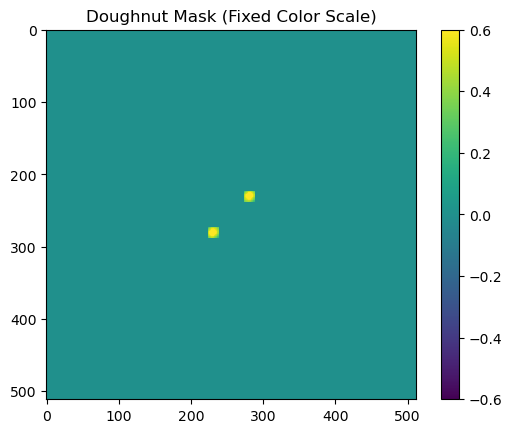

In [13]:
import matplotlib.pyplot as plt

plt.imshow(mask, cmap='viridis', interpolation='nearest', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Doughnut Mask (Fixed Color Scale)')
plt.show()

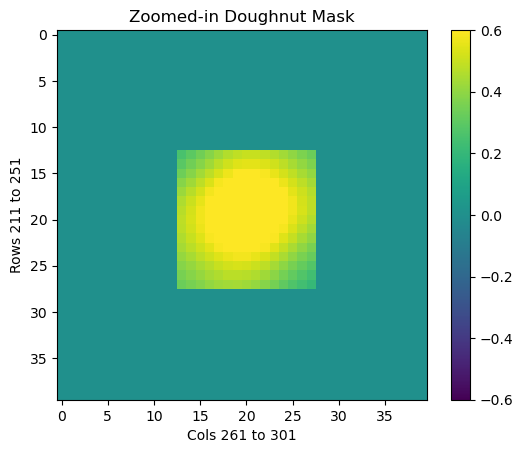

In [14]:
# Zoom range
zoom_radius = 20
r_start = max(dot_r - zoom_radius, 0)
r_end   = dot_r + zoom_radius
c_start = max(dot_c - zoom_radius, 0)
c_end   = dot_c + zoom_radius

# Plot zoomed-in region
plt.imshow(mask[r_start:r_end, c_start:c_end], 
           cmap='viridis', interpolation='nearest', vmin=-0.6, vmax=0.6)
plt.colorbar()
plt.title('Zoomed-in Doughnut Mask')
plt.xlabel(f'Cols {c_start} to {c_end}')
plt.ylabel(f'Rows {r_start} to {r_end}')
plt.show()

In [15]:
mask.shape

(512, 512)

In [16]:
dots_mask_vector = upper_triangular_to_vector_skip_two_diagonals(mask)
dots_mask_vector_tensor = torch.tensor(dots_mask_vector).to(device)

In [17]:
fragment_bool_mask  = mask != 0

In [18]:
fragment_bool_mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [19]:
dots_mask_indices = fragment_indices_in_upper_triangular(matrix_size=size, fragment_mask=fragment_bool_mask)
dots_mask_indices_tensor = torch.tensor(dots_mask_indices)

In [20]:
len(dots_mask_indices_tensor)

225

In [ ]:
# torch.save(dots_mask_indices_tensor, "/scratch1/smaruj/generate_genomic_dot/dots_indices.pt")

In [21]:
len(df)

58

In [22]:
for row in df.itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    sequence = genome[row.chrom][pred_start:pred_end]
    
    X = one_hot_encode_sequence(sequence)
    X_tensor = torch.tensor(X)
    
    model.eval()
    with torch.no_grad():
        y = model(X_tensor)
    
    # y = y.to(device)
    # summing up map + mask
    # y_bar = y[0, 0, :] + dots_mask_vector_tensor
    # y_bar = y_bar.unsqueeze(0).unsqueeze(0)
    
    # replacing values of map with the mask
    y_bar = y.to(device).clone()
    masked_values = dots_mask_vector_tensor[dots_mask_indices_tensor].float()
    y_bar[0, 0, dots_mask_indices_tensor] = masked_values.to(device)
    
    torch.save(y_bar, f"/scratch1/smaruj/generate_genomic_dot/targets/target_{c}/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt")
    # torch.save(y, f"/scratch1/smaruj/genomic_insertion_loci/genomic_targets/fold{FOLD}/{chrom}_{pred_start}_{pred_end}_target.pt")